In [2]:
import sys
sys.path.insert(0, '..')
from dependencies import *

envelopes_log = eelbrain.load.unpickle(PROCESSED_PREDICTOR_DIR / f'~processed_envelopes-log.pickle')
subject_model_predictors = eelbrain.load.unpickle(PREDICTOR_DIR / f'~concatenated_predictors.pickle')
durations = get_durations(envelopes_log)
models = get_models()

In [ ]:
subject = 'S05'
model = 'envelope_log_8band'
trf_encoder = eelbrain.load.unpickle(TRF_DIR / f'{subject}' / f'{subject} {model}.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
predictor = subject_model_predictors[subject][model]

print(trf_encoder)
print(trf_encoder.h_scaled)
print(predictor)

eeg_predicted = eelbrain.convolve(trf_encoder.h_scaled[0], predictor) # Right now is a tuple, re-run estimate TRFs to get new
print(eeg_predicted)

<BoostingResult None ~ envelope_log_8band, -0.1 - 1, error=l1, basis=0.05, partitions=5, test=1, selective_stopping=1>
(<NDVar 'envelope_log_8band': 55 sensor, 8 frequency, 114 time>,)
<NDVar 'envelope_log_8band': 8 frequency, 73677 time>
<NDVar 'envelope_log_8band': 55 sensor, 73677 time>


/Users/drmanistein/miniforge3/envs/eelbrain/lib/python3.13/site-packages/eelbrain/plot/_base.py:1741: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self.figure.tight_layout()


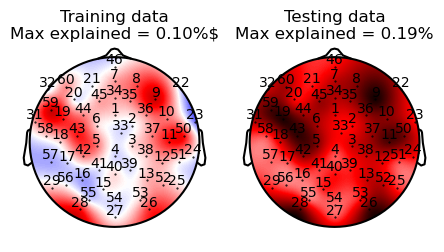

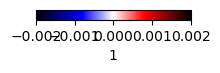

In [ ]:
# Evaluate cross-validated predictions
ss_total = eeg.abs().sum('time')
ss_residual = (eeg - eeg_predicted).abs().sum('time')
proportion_explained = 1 - (ss_residual / ss_total)
# Plot correlation on estimation and testing data
titles = [f'Training data\nMax explained = {trf_encoder.proportion_explained.max():.2%}$', f'Testing data\nMax explained = {proportion_explained.max():.2%}']
p = eelbrain.plot.Topomap([trf_encoder.proportion_explained, proportion_explained], sensorlabels='name', clip='circle', rows=1, axtitle=titles)
p_cb = p.plot_colorbar(width=.1, w=2)

# Predict using the universal TRF

In [4]:
subject = 'S05'
model = 'envelope_log'
trf_encoder = eelbrain.load.unpickle(TRF_DIR / 'universal-trf-average.pickle')
eeg = eelbrain.load.unpickle(STIMULUS_DIR / f'{subject}concatenated_eeg.pickle')
predictor = subject_model_predictors[subject][model]

print(trf_encoder)
print(trf_encoder)
print(predictor)

eeg_predicted = eelbrain.convolve(trf_encoder, predictor) # Right now is a tuple, re-run estimate TRFs to get new
print(eeg_predicted)

<NDVar 'envelope_onset': 8 sensor, 114 time>
<NDVar 'envelope_onset': 8 sensor, 114 time>
<NDVar 'envelope_onset': 73677 time>
<NDVar 'envelope_onset': 8 sensor, 73677 time>


/Users/drmanistein/miniforge3/envs/eelbrain/lib/python3.13/site-packages/eelbrain/plot/_base.py:1741: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self.figure.tight_layout()


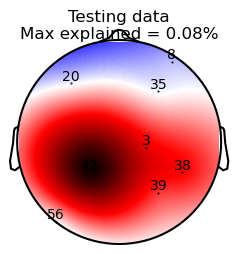

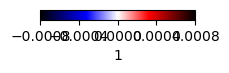

In [8]:
# Evaluate cross-validated predictions
ss_total = ((eeg - eeg.mean('time')) ** 2).sum('time')
ss_residual = ((eeg - eeg_predicted) ** 2).sum('time')
proportion_explained = 1 - (ss_residual / ss_total)

# Plot topography of explained variance
title = f'Testing data\nMax explained = {proportion_explained.max():.2%}'
p = eelbrain.plot.Topomap(proportion_explained, sensorlabels='name', clip='circle', axtitle=title)
p_cb = p.plot_colorbar(width=.1, w=2)